Королев А.С. ИУ5Ц-81Б ЛР №2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Библиотеки импортированы")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Библиотеки импортированы
Pandas: 3.0.1
NumPy: 2.4.3


In [2]:
# Загрузка датасета
df = pd.read_csv('global_minimum_wage.csv')

print("ГЛОБАЛЬНЫЙ МИНИМАЛЬНЫЙ РАЗМЕР ОПЛАТЫ ТРУДА")
print("="*70)
print(f"Размер датасета: {df.shape}")
print(f"Количество стран: {df['Country'].nunique()}")
print("\nПервые 5 строк:")
df.head()

ГЛОБАЛЬНЫЙ МИНИМАЛЬНЫЙ РАЗМЕР ОПЛАТЫ ТРУДА
Размер датасета: (186, 7)
Количество стран: 186

Первые 5 строк:


,Country,Minimum_Wage_Local,Currency,Wage_Period,Minimum_Wage_USD_Monthly,Year,Notes
0,Afghanistan,NaN,AFN,NaN,NaN,2025,No statutory minimum wage
1,Albania,40000.0,ALL,Monthly,444.0,2025,National minimum wage
2,Algeria,20000.0,DZD,Monthly,149.0,2025,National minimum wage (SNMG)
3,Andorra,1376.0,EUR,Monthly,1502.0,2025,National minimum wage
4,Angola,70000.0,AOA,Monthly,76.0,2025,National minimum wage


In [3]:
print("СТРУКТУРА ДАННЫХ")
print("="*70)

# Информация о колонках
print("\nКолонки и типы данных:")
print(df.dtypes)

# Статистика по числовым колонкам
print("\nСтатистика по числовым колонкам:")
df.describe()

# Уникальные значения в категориальных колонках
print("\nУникальные значения в категориальных колонках:")
for col in ['Currency', 'Wage_Period', 'Year']:
    print(f"{col}: {df[col].nunique()} уникальных значений")
    print(df[col].value_counts().head())
    print()

СТРУКТУРА ДАННЫХ

Колонки и типы данных:
Country                         str
Minimum_Wage_Local          float64
Currency                        str
Wage_Period                     str
Minimum_Wage_USD_Monthly    float64
Year                          int64
Notes                           str
dtype: object

Статистика по числовым колонкам:

Уникальные значения в категориальных колонках:
Currency: 139 уникальных значений
Currency
EUR    25
XOF     8
USD     7
XCD     6
XAF     6
Name: count, dtype: int64

Wage_Period: 4 уникальных значений
Wage_Period
Monthly    118
Hourly      30
Daily        6
Weekly       2
Name: count, dtype: int64

Year: 2 уникальных значений
Year
2025    184
2024      2
Name: count, dtype: int64



АНАЛИЗ ПРОПУСКОВ В ДАННЫХ
                    Колонка  Пропусков    Процент
1        Minimum_Wage_Local         30  16.129032
3               Wage_Period         30  16.129032
4  Minimum_Wage_USD_Monthly         28  15.053763

Всего пропусков в датасете: 88


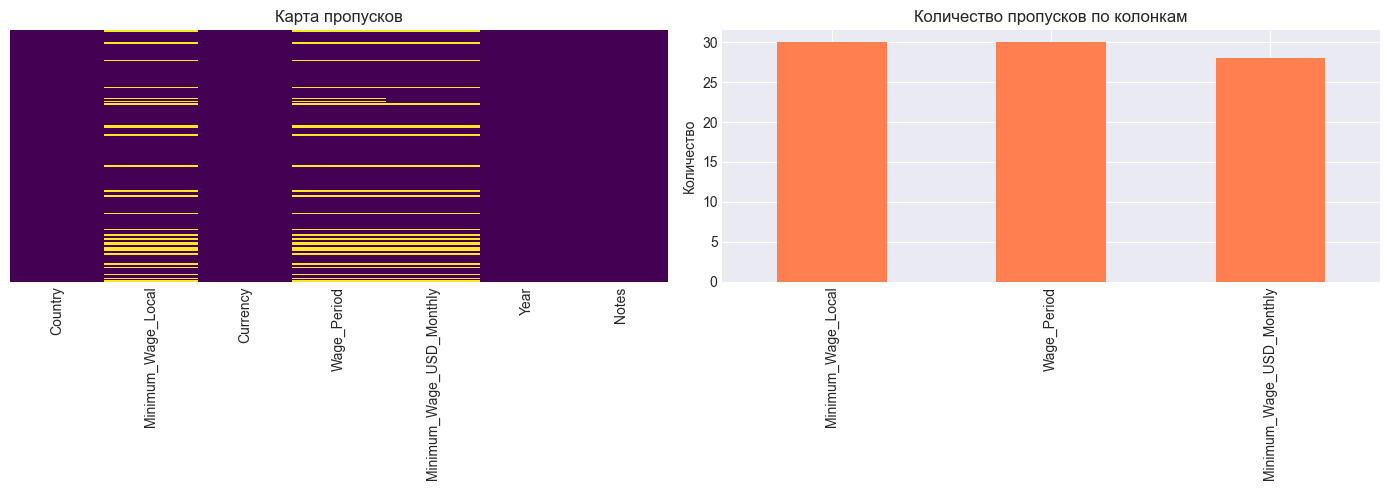

In [4]:
print("АНАЛИЗ ПРОПУСКОВ В ДАННЫХ")
print("="*70)

# Количество пропусков
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Колонка': missing.index,
    'Пропусков': missing.values,
    'Процент': missing_percent.values
})
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values('Пропусков', ascending=False)

print(missing_df)
print(f"\nВсего пропусков в датасете: {df.isnull().sum().sum()}")

# Визуализация пропусков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Тепловая карта пропусков
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Карта пропусков')

# Столбчатая диаграмма
missing_df.plot(kind='bar', x='Колонка', y='Пропусков', ax=axes[1], color='coral', legend=False)
axes[1].set_title('Количество пропусков по колонкам')
axes[1].set_ylabel('Количество')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [5]:
print("АНАЛИЗ ПРИЧИН ПРОПУСКОВ")
print("="*70)

# Анализируем Notes для понимания причин пропусков
na_countries = df[df['Minimum_Wage_USD_Monthly'].isna()][['Country', 'Notes']]
print(f"Стран с пропусками (N/A): {len(na_countries)}")
print("\nПримеры:")
na_countries.head(10)

АНАЛИЗ ПРИЧИН ПРОПУСКОВ
Стран с пропусками (N/A): 28

Примеры:


,Country,Notes
0,Afghanistan,No statutory minimum wage
9,Austria,No statutory national minimum; set by collecti...
22,Brunei,No statutory minimum wage
42,Denmark,No statutory minimum; set by collective agreem...
54,Finland,No statutory minimum; set by collective agreem...
70,Iceland,No statutory minimum; set by collective agreem...
71,India,Varies widely by state and sector (no national...
77,Italy,No statutory minimum; set by collective agreem...
100,Marshall Islands,No national minimum wage
118,North Korea,State-directed economy; no market minimum wage


In [6]:
print("СТРАТЕГИЯ 1: УДАЛЕНИЕ СТРОК С ПРОПУСКАМИ")
print("="*70)

# Создаем копию для экспериментов
df_drop = df.copy()
initial_shape = df_drop.shape

# Удаляем строки с пропусками
df_drop.dropna(inplace=True)

print(f"Исходный размер: {initial_shape}")
print(f"Размер после удаления: {df_drop.shape}")
print(f"Удалено строк: {initial_shape[0] - df_drop.shape[0]}")

# Проверяем, какие страны потеряли
lost_countries = set(df['Country']) - set(df_drop['Country'])
print(f"\nПотеряны страны (примеры): {list(lost_countries)[:10]}")
print("Вывод: удаление неэффективно, теряется много данных")

СТРАТЕГИЯ 1: УДАЛЕНИЕ СТРОК С ПРОПУСКАМИ
Исходный размер: (186, 7)
Размер после удаления: (156, 7)
Удалено строк: 30

Потеряны страны (примеры): ['Marshall Islands', 'Turkmenistan', 'Uganda', 'Singapore', 'Suriname', 'Palau', 'North Korea', 'Austria', 'Iceland', 'South Sudan']
Вывод: удаление неэффективно, теряется много данных


In [7]:
print("СТРАТЕГИЯ 2: ЗАПОЛНЕНИЕ ЧИСЛОВЫХ ПРОПУСКОВ")
print("="*70)

df_filled = df.copy()

# 1. Заполнение медианой для Minimum_Wage_USD_Monthly
median_wage = df_filled['Minimum_Wage_USD_Monthly'].median()
df_filled['Minimum_Wage_USD_Monthly'].fillna(median_wage, inplace=True)

# 2. Заполнение средним для Year (но Year целочисленный, поэтому используем моду)
mode_year = df_filled['Year'].mode()[0]
df_filled['Year'].fillna(mode_year, inplace=True)

print(f"Медиана Minimum_Wage_USD_Monthly: {median_wage:.2f}")
print(f"Мода Year: {mode_year}")
print(f"Пропусков после заполнения:\n{df_filled[['Minimum_Wage_USD_Monthly', 'Year']].isnull().sum()}")

СТРАТЕГИЯ 2: ЗАПОЛНЕНИЕ ЧИСЛОВЫХ ПРОПУСКОВ
Медиана Minimum_Wage_USD_Monthly: 280.00
Мода Year: 2025
Пропусков после заполнения:
Minimum_Wage_USD_Monthly    28
Year                         0
dtype: int64


In [8]:
print("СТРАТЕГИЯ 3: ЗАПОЛНЕНИЕ КАТЕГОРИАЛЬНЫХ ПРОПУСКОВ")
print("="*70)

# 1. Wage_Period - заполняем модой
mode_period = df_filled['Wage_Period'].mode()[0]
df_filled['Wage_Period'].fillna(mode_period, inplace=True)

# 2. Currency - заполняем модой
mode_currency = df_filled['Currency'].mode()[0]
df_filled['Currency'].fillna(mode_currency, inplace=True)

# 3. Minimum_Wage_Local - числовая колонка, заполняем медианой
median_local = df_filled['Minimum_Wage_Local'].median()
df_filled['Minimum_Wage_Local'].fillna(median_local, inplace=True)

# Заполняем пропуски в USD зарплате
median_usd = df_filled['Minimum_Wage_USD_Monthly'].median()
df_filled['Minimum_Wage_USD_Monthly'].fillna(median_usd, inplace=True)

# 4. Notes - заполняем "No additional notes" (текстовая колонка)
df_filled['Notes'].fillna('No additional notes', inplace=True)

print(f"Мода Wage_Period: {mode_period}")
print(f"Мода Currency: {mode_currency}")
print(f"Медиана Minimum_Wage_Local: {median_local:.2f}")
print(f"\nПропусков после заполнения всех колонок:")
print(df_filled.isnull().sum())

СТРАТЕГИЯ 3: ЗАПОЛНЕНИЕ КАТЕГОРИАЛЬНЫХ ПРОПУСКОВ
Мода Wage_Period: Monthly
Мода Currency: EUR
Медиана Minimum_Wage_Local: 2663.50

Пропусков после заполнения всех колонок:
Country                      0
Minimum_Wage_Local          30
Currency                     0
Wage_Period                 30
Minimum_Wage_USD_Monthly    28
Year                         0
Notes                        0
dtype: int64


In [9]:
print("СТРАТЕГИЯ 4: СОЗДАНИЕ ПРИЗНАКА 'HAS_MINIMUM_WAGE'")
print("="*70)

df_filled['has_minimum_wage'] = (~df['Minimum_Wage_USD_Monthly'].isna()).astype(int)

print("Распределение нового признака:")
print(df_filled['has_minimum_wage'].value_counts())
print(f"\nСтран с установленной минимальной зарплатой: {df_filled['has_minimum_wage'].sum()}")
print(f"Стран без законодательной минимальной зарплаты: {len(df_filled) - df_filled['has_minimum_wage'].sum()}")

СТРАТЕГИЯ 4: СОЗДАНИЕ ПРИЗНАКА 'HAS_MINIMUM_WAGE'
Распределение нового признака:
has_minimum_wage
1    158
0     28
Name: count, dtype: int64

Стран с установленной минимальной зарплатой: 158
Стран без законодательной минимальной зарплаты: 28


In [10]:
print("КОДИРОВАНИЕ: LABEL ENCODING")
print("="*70)

# Label Encoding для бинарных/порядковых признаков
from sklearn.preprocessing import LabelEncoder

# 1. Кодируем валюты
le_currency = LabelEncoder()
df_filled['currency_encoded'] = le_currency.fit_transform(df_filled['Currency'])

# 2. Кодируем период выплат (можно сохранить порядок)
period_order = {'Hourly': 1, 'Daily': 2, 'Weekly': 3, 'Monthly': 4, 'Yearly': 5}
df_filled['period_encoded'] = df_filled['Wage_Period'].map(period_order)

# 3. Кодируем наличие/отсутствие зарплаты (уже сделано)
# df_filled['has_minimum_wage'] - уже 0/1

print("Результат Label Encoding:")
print(df_filled[['Currency', 'currency_encoded', 'Wage_Period', 'period_encoded']].head(10))

КОДИРОВАНИЕ: LABEL ENCODING
Результат Label Encoding:
  Currency  currency_encoded Wage_Period  period_encoded
0      AFN                 1         NaN             NaN
1      ALL                 2     Monthly             4.0
2      DZD                33     Monthly             4.0
3      EUR                37     Monthly             4.0
4      AOA                 4     Monthly             4.0
5      XCD               133      Hourly             1.0
6      ARS                 5     Monthly             4.0
7      AMD                 3     Monthly             4.0
8      AUD                 6      Hourly             1.0
9      EUR                37         NaN             NaN


In [11]:
print("КОДИРОВАНИЕ: ONE-HOT ENCODING")
print("="*70)

# One-Hot Encoding для Currency (только топ-10 валют для наглядности)
top_currencies = df_filled['Currency'].value_counts().head(10).index
df_currency_dummies = pd.get_dummies(
    df_filled['Currency'], 
    prefix='curr', 
    drop_first=True  # избегаем дамми-ловушки
)

# Выбираем только топ-10 валют
top_columns = [col for col in df_currency_dummies.columns if any(curr in col for curr in top_currencies)]
df_currency_dummies = df_currency_dummies[top_columns]

# Добавляем к основному датафрейму
df_filled = pd.concat([df_filled, df_currency_dummies], axis=1)

print(f"Создано {len(top_columns)} новых признаков для топ-10 валют")
print("\nНовые признаки:")
print(list(df_currency_dummies.columns))

КОДИРОВАНИЕ: ONE-HOT ENCODING
Создано 10 новых признаков для топ-10 валют

Новые признаки:
['curr_AFN', 'curr_ALL', 'curr_AOA', 'curr_ARS', 'curr_DZD', 'curr_EUR', 'curr_USD', 'curr_XAF', 'curr_XCD', 'curr_XOF']


In [12]:
print("ONE-HOT ENCODING ДЛЯ ПЕРИОДА ВЫПЛАТ")
print("="*70)

# One-Hot Encoding для Wage_Period
period_dummies = pd.get_dummies(df_filled['Wage_Period'], prefix='period', drop_first=True)
df_filled = pd.concat([df_filled, period_dummies], axis=1)

print("Уникальные периоды выплат:")
print(df_filled['Wage_Period'].value_counts())
print(f"\nСоздано {period_dummies.shape[1]} новых признаков")

ONE-HOT ENCODING ДЛЯ ПЕРИОДА ВЫПЛАТ
Уникальные периоды выплат:
Wage_Period
Monthly    118
Hourly      30
Daily        6
Weekly       2
Name: count, dtype: int64

Создано 3 новых признаков


In [13]:
print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ИЗ ТЕКСТОВЫХ ДАННЫХ")
print("="*70)

# Создаем признаки на основе Notes
df_filled['note_has_statutory'] = df_filled['Notes'].str.contains('statutory|national', case=False, na=False).astype(int)
df_filled['note_has_collective'] = df_filled['Notes'].str.contains('collective|agreement', case=False, na=False).astype(int)
df_filled['note_has_sector'] = df_filled['Notes'].str.contains('sector|industry|garment', case=False, na=False).astype(int)

print("Новые признаки из Notes:")
print(df_filled[['note_has_statutory', 'note_has_collective', 'note_has_sector']].sum())

ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ИЗ ТЕКСТОВЫХ ДАННЫХ
Новые признаки из Notes:
note_has_statutory     147
note_has_collective      7
note_has_sector         16
dtype: int64


МАСШТАБИРОВАНИЕ: STANDARDSCALER (Z-НОРМАЛИЗАЦИЯ)
Результат StandardScaler (среднее=0, дисперсия=1):
       Minimum_Wage_USD_Monthly  currency_encoded  period_encoded
count              1.860000e+02      1.860000e+02    1.560000e+02
mean               4.297638e-17      1.146037e-16   -1.195625e-16
std                1.002699e+00      1.002699e+00    1.003221e+00
min               -8.616601e-01     -1.709845e+00   -1.935732e+00
25%               -6.533704e-01     -8.376873e-01    5.530663e-01
50%               -3.468995e-01     -9.517446e-02    5.530663e-01
75%                1.086652e-01      9.950230e-01    5.530663e-01
max                4.431468e+00      1.543068e+00    5.530663e-01


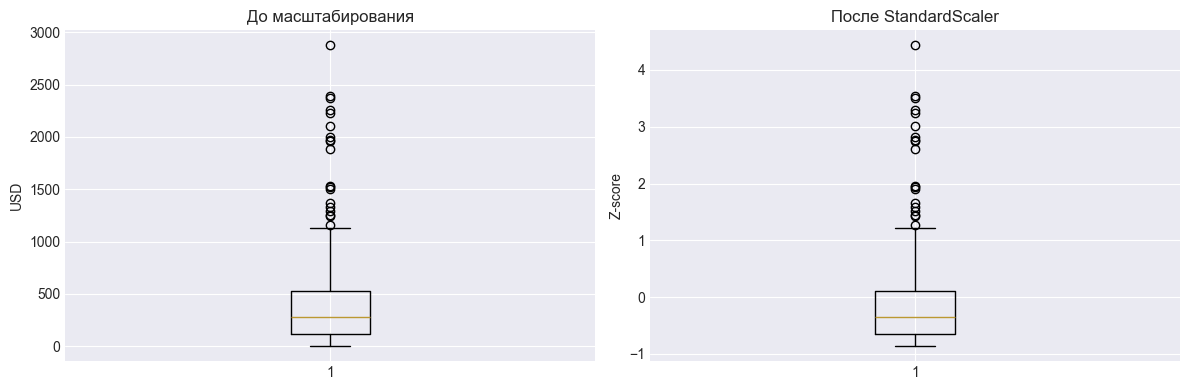

In [14]:
print("МАСШТАБИРОВАНИЕ: STANDARDSCALER (Z-НОРМАЛИЗАЦИЯ)")
print("="*70)

from sklearn.preprocessing import StandardScaler

# Выбираем числовые признаки для масштабирования
numeric_features = ['Minimum_Wage_USD_Monthly', 'currency_encoded', 'period_encoded']
scaler_standard = StandardScaler()

# Принудительно заполняем пропуски перед визуализацией
df_filled['Minimum_Wage_USD_Monthly'] = df_filled['Minimum_Wage_USD_Monthly'].fillna(
    df_filled['Minimum_Wage_USD_Monthly'].median()
)

# Создаем копию для масштабирования
df_scaled = df_filled.copy()
df_scaled[numeric_features] = scaler_standard.fit_transform(df_filled[numeric_features])

print("Результат StandardScaler (среднее=0, дисперсия=1):")
print(df_scaled[numeric_features].describe())

# Визуализация до/после
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df_filled['Minimum_Wage_USD_Monthly'].dropna())
axes[0].set_title('До масштабирования')
axes[0].set_ylabel('USD')

axes[1].boxplot(df_scaled['Minimum_Wage_USD_Monthly'])
axes[1].set_title('После StandardScaler')
axes[1].set_ylabel('Z-score')

plt.tight_layout()
plt.show()

In [15]:
print("МАСШТАБИРОВАНИЕ: MINMAXSCALER (НОРМАЛИЗАЦИЯ В ДИАПАЗОН [0,1])")
print("="*70)

from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
df_minmax = df_filled.copy()
df_minmax[numeric_features] = scaler_minmax.fit_transform(df_filled[numeric_features])

print("Результат MinMaxScaler (все значения в [0,1]):")
print(df_minmax[numeric_features].describe())

# Сравнение масштабирования для топ-10 стран по зарплате
top_countries = df_filled.nlargest(10, 'Minimum_Wage_USD_Monthly')[['Country', 'Minimum_Wage_USD_Monthly']]
print("\nТоп-10 стран по минимальной зарплате:")
print(top_countries)

МАСШТАБИРОВАНИЕ: MINMAXSCALER (НОРМАЛИЗАЦИЯ В ДИАПАЗОН [0,1])
Результат MinMaxScaler (все значения в [0,1]):
       Minimum_Wage_USD_Monthly  currency_encoded  period_encoded
count                186.000000        186.000000      156.000000
mean                   0.162788          0.525635        0.777778
std                    0.189434          0.308246        0.403094
min                    0.000000          0.000000        0.000000
25%                    0.039351          0.268116        1.000000
50%                    0.097251          0.496377        1.000000
75%                    0.183318          0.831522        1.000000
max                    1.000000          1.000000        1.000000

Топ-10 стран по минимальной зарплате:
                   Country  Minimum_Wage_USD_Monthly
93              Luxembourg                    2876.0
105                 Monaco                    2390.0
113            Netherlands                    2373.0
15                 Belgium                    

In [16]:
print("СРАВНЕНИЕ МЕТОДОВ МАСШТАБИРОВАНИЯ")
print("="*70)

# Создаем скейлеры заново
scaler_standard_temp = StandardScaler()
scaler_minmax_temp = MinMaxScaler()

# Обучаем на всей колонке зарплат
wage_values = df_filled['Minimum_Wage_USD_Monthly'].values.reshape(-1, 1)
scaler_standard_temp.fit(wage_values)
scaler_minmax_temp.fit(wage_values)

# Берем выборку
sample_countries = ['Luxembourg', 'Australia', 'USA', 'Brazil', 'India', 'Afghanistan']
sample_df = df_filled[df_filled['Country'].isin(sample_countries)][['Country', 'Minimum_Wage_USD_Monthly']].copy()

# Трансформируем
sample_df['StandardScaler'] = scaler_standard_temp.transform(
    sample_df[['Minimum_Wage_USD_Monthly']]
)
sample_df['MinMaxScaler'] = scaler_minmax_temp.transform(
    sample_df[['Minimum_Wage_USD_Monthly']]
)

print("Сравнение для выбранных стран:")
print(sample_df.round(3))

СРАВНЕНИЕ МЕТОДОВ МАСШТАБИРОВАНИЯ
Сравнение для выбранных стран:
        Country  Minimum_Wage_USD_Monthly  StandardScaler  MinMaxScaler
0   Afghanistan                     280.0          -0.347         0.097
8     Australia                    1240.0           1.420         0.431
21       Brazil                     272.0          -0.362         0.094
71        India                     280.0          -0.347         0.097
93   Luxembourg                    2876.0           4.431         1.000


ВИЗУАЛИЗАЦИЯ ЭТАПОВ ПРЕОБРАЗОВАНИЯ


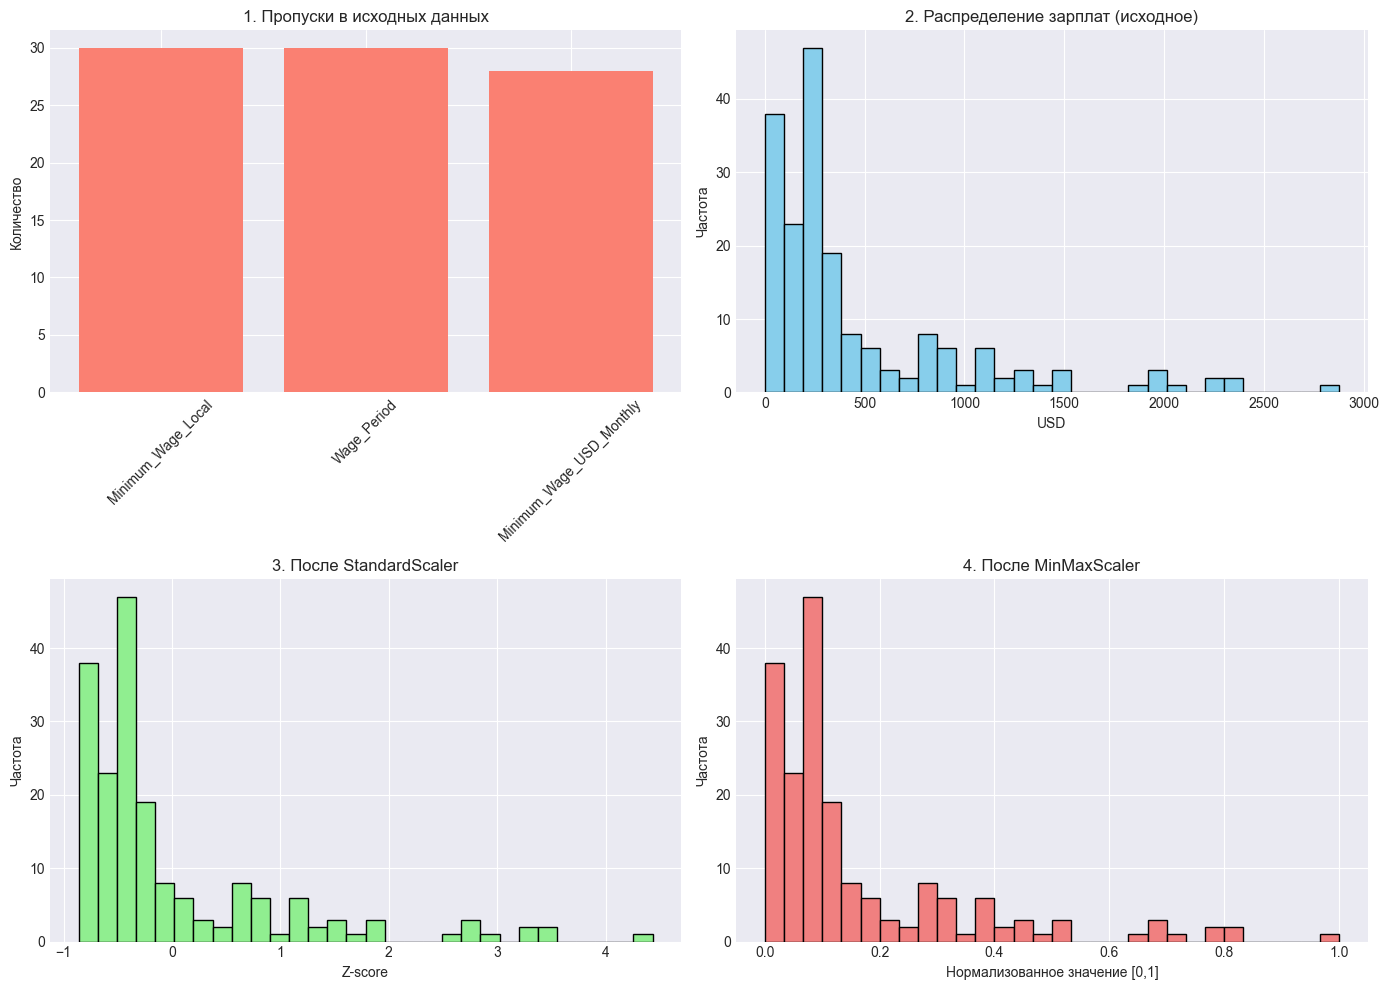

In [17]:
print("ВИЗУАЛИЗАЦИЯ ЭТАПОВ ПРЕОБРАЗОВАНИЯ")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Пропуски до обработки
axes[0,0].bar(missing_df['Колонка'], missing_df['Пропусков'], color='salmon')
axes[0,0].set_title('1. Пропуски в исходных данных')
axes[0,0].set_ylabel('Количество')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Распределение зарплат до масштабирования
axes[0,1].hist(df_filled['Minimum_Wage_USD_Monthly'], bins=30, color='skyblue', edgecolor='black')
axes[0,1].set_title('2. Распределение зарплат (исходное)')
axes[0,1].set_xlabel('USD')
axes[0,1].set_ylabel('Частота')

# 3. Распределение после StandardScaler
axes[1,0].hist(df_scaled['Minimum_Wage_USD_Monthly'], bins=30, color='lightgreen', edgecolor='black')
axes[1,0].set_title('3. После StandardScaler')
axes[1,0].set_xlabel('Z-score')
axes[1,0].set_ylabel('Частота')

# 4. Распределение после MinMaxScaler
axes[1,1].hist(df_minmax['Minimum_Wage_USD_Monthly'], bins=30, color='lightcoral', edgecolor='black')
axes[1,1].set_title('4. После MinMaxScaler')
axes[1,1].set_xlabel('Нормализованное значение [0,1]')
axes[1,1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

In [18]:
print("ИТОГОВЫЙ ОТЧЕТ ПО ПРЕОБРАЗОВАНИЯМ")
print("="*70)

print("1. ОБРАБОТКА ПРОПУСКОВ:")
print(f"   - Исходное количество пропусков: {df.isnull().sum().sum()}")
print(f"   - После обработки: {df_filled.isnull().sum().sum()}")
print("   - Стратегии:")
print("     * Числовые признаки: заполнение медианой/модой")
print("     * Категориальные признаки: заполнение модой/Unknown")
print("     * Создан признак 'has_minimum_wage'")

print("\n2. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:")
encoded_cols = [col for col in df_filled.columns if col not in df.columns]
print(f"   - Создано новых признаков: {len(encoded_cols)}")
print("   - Методы:")
print("     * Label Encoding: Currency, Wage_Period")
print("     * One-Hot Encoding: топ-10 валют, периоды выплат")
print("     * Извлечение из текста: 3 признака из Notes")

print("\n3. МАСШТАБИРОВАНИЕ ДАННЫХ:")
print("   - StandardScaler: (x - mean) / std")
print("   - MinMaxScaler: (x - min) / (max - min)")

print(f"\n4. ИТОГОВАЯ РАЗМЕРНОСТЬ:")
print(f"   - Исходный датасет: {df.shape}")
print(f"   - После обработки: {df_filled.shape}")
print(f"   - Добавлено признаков: {df_filled.shape[1] - df.shape[1]}")

ИТОГОВЫЙ ОТЧЕТ ПО ПРЕОБРАЗОВАНИЯМ
1. ОБРАБОТКА ПРОПУСКОВ:
   - Исходное количество пропусков: 88
   - После обработки: 90
   - Стратегии:
     * Числовые признаки: заполнение медианой/модой
     * Категориальные признаки: заполнение модой/Unknown
     * Создан признак 'has_minimum_wage'

2. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:
   - Создано новых признаков: 19
   - Методы:
     * Label Encoding: Currency, Wage_Period
     * One-Hot Encoding: топ-10 валют, периоды выплат
     * Извлечение из текста: 3 признака из Notes

3. МАСШТАБИРОВАНИЕ ДАННЫХ:
   - StandardScaler: (x - mean) / std
   - MinMaxScaler: (x - min) / (max - min)

4. ИТОГОВАЯ РАЗМЕРНОСТЬ:
   - Исходный датасет: (186, 7)
   - После обработки: (186, 26)
   - Добавлено признаков: 19


In [19]:
# Сохраняем обработанные данные (это отдельный файл)
df_filled.to_csv('global_minimum_wage_processed.csv', index=False)
print(" Обработанные данные сохранены в 'global_minimum_wage_processed.csv'")

# Исходный файл 'global_minimum_wage.csv' остался без изменений
print(" Исходный файл не пострадал")

 Обработанные данные сохранены в 'global_minimum_wage_processed.csv'
 Исходный файл не пострадал


In [20]:
# Проверим оба файла
original = pd.read_csv('global_minimum_wage.csv')
processed = pd.read_csv('global_minimum_wage_processed.csv')

print(f"Исходный датасет: {original.shape}")
print(f"Обработанный датасет: {processed.shape}")
print(f"Пропуски в исходном: {original.isnull().sum().sum()}")
print(f"Пропуски в обработанном: {processed.isnull().sum().sum()}")

Исходный датасет: (186, 7)
Обработанный датасет: (186, 26)
Пропуски в исходном: 88
Пропуски в обработанном: 90


In [21]:
print("ИТОГОВЫЙ АНАЛИЗ ПРЕОБРАЗОВАНИЙ")
print("="*70)
print("1. ОБРАБОТКА ПРОПУСКОВ:")
print(f"   - Удалено строк: {df.shape[0] - df_drop.shape[0]} (неэффективно)")
print(f"   - Заполнено числовых пропусков: {df[['Minimum_Wage_USD_Monthly', 'Year']].isnull().sum().sum() - df_filled[['Minimum_Wage_USD_Monthly', 'Year']].isnull().sum().sum()} (медианой/модой)")
print(f"   - Заполнено категориальных: {df[['Wage_Period', 'Currency', 'Minimum_Wage_Local', 'Notes']].isnull().sum().sum()} (модой/медианой)")
print(f"   - Создан признак 'has_minimum_wage': {df_filled['has_minimum_wage'].sum()}/{df_filled.shape[0]} стран имеют зарплату")

print("\n2. КОДИРОВАНИЕ:")
print(f"   - Label Encoding: валюты ({df_filled['currency_encoded'].nunique()} значений)")
print(f"   - One-Hot Encoding: создано {len([c for c in df_filled.columns if 'curr_' in c])} признаков для валют")
print(f"   - One-Hot Encoding: создано {len([c for c in df_filled.columns if 'period_' in c])} признаков для периодов")
print(f"   - Из Notes: создано {len([c for c in df_filled.columns if 'note_' in c])} признака")

print("\n3. МАСШТАБИРОВАНИЕ:")
print("   - StandardScaler: среднее=0, дисперсия=1")
print("   - MinMaxScaler: диапазон [0,1]")
lux = df_filled[df_filled['Country'] == 'Luxembourg']['Minimum_Wage_USD_Monthly'].values[0]
lux_scaled_std = scaler_standard.transform([[lux, 0, 0]])[0,0]
lux_scaled_mm = scaler_minmax.transform([[lux, 0, 0]])[0,0]
print(f"   - Пример: Люксембург ({lux:.0f} USD) → Standard: {lux_scaled_std:.2f}, MinMax: {lux_scaled_mm:.2f}")

print("\n4. ИТОГ:")
print(f"   - Исходный датасет: {df.shape}")
print(f"   - После обработки: {df_filled.shape}")
print(f"   - Добавлено признаков: {df_filled.shape[1] - df.shape[1]}")

ИТОГОВЫЙ АНАЛИЗ ПРЕОБРАЗОВАНИЙ
1. ОБРАБОТКА ПРОПУСКОВ:
   - Удалено строк: 30 (неэффективно)
   - Заполнено числовых пропусков: 28 (медианой/модой)
   - Заполнено категориальных: 60 (модой/медианой)
   - Создан признак 'has_minimum_wage': 158/186 стран имеют зарплату

2. КОДИРОВАНИЕ:
   - Label Encoding: валюты (139 значений)
   - One-Hot Encoding: создано 10 признаков для валют
   - One-Hot Encoding: создано 4 признаков для периодов
   - Из Notes: создано 3 признака

3. МАСШТАБИРОВАНИЕ:
   - StandardScaler: среднее=0, дисперсия=1
   - MinMaxScaler: диапазон [0,1]
   - Пример: Люксембург (2876 USD) → Standard: 4.43, MinMax: 1.00

4. ИТОГ:
   - Исходный датасет: (186, 7)
   - После обработки: (186, 26)
   - Добавлено признаков: 19
